In [ ]:
from __future__ import annotations

import random

import numpy as np
import plotly.graph_objects as go
from pymatgen.core import Composition, Element

elements = ["Bi", "Te", "In"]

import itertools

from smact.screening import smact_validity

max_stoich = 8
all_compositions = [
    Composition({el: amt for el, amt in zip(elements, amt_list)}).reduced_composition
    for amt_list in itertools.product(range(max_stoich + 1), repeat=len(elements))
    if max(amt_list) > 0
]
valid_compositions = [
    comp for comp in all_compositions if smact_validity(comp)
]  # add ox threshold and see if it makes the phase diagram tighter-
unique_valid_compositions = list(set(valid_compositions))
print(f"Number of unique valid compositions: {len(unique_valid_compositions)} out of {len(all_compositions)}")

from smact.utils.oxidation import ICSD24OxStatesFilter

# Initialise the oxidation state filter
ox_filter = ICSD24OxStatesFilter()
ox_states_df = ox_filter.ox_states_df
ox_states_df.head(15)

supplied_oxidation_states = [
    "smact14",
    "icsd24",
    "icsd16",
    "pymatgen_sp",
    "oxidation_states_icsd24_100.txt",
]
# Extract fractional compositions
e1 = np.array([comp[elements[0]] for comp in unique_valid_compositions])
e2 = np.array([comp[elements[1]] for comp in unique_valid_compositions])
e3 = np.array([comp[elements[2]] for comp in unique_valid_compositions])

# Normalize to get fractions
total = e1 + e2 + e3
e1 = e1 / total
e2 = e2 / total
e3 = e3 / total

# plot with line from origin_fig
fig = go.Figure()
# mp entries
fig.add_trace(
    go.Scatterternary(
        a=e1,
        b=e2,
        c=e3,
        mode="markers",
        marker=dict(
            size=6,
            color="green",
            symbol="circle",
            opacity=0.7,
        ),
        name="SMACT Valid",
        cliponaxis=False,
    )
)
# layout
axis_style = dict(
    title=dict(font=dict(size=10)),
    linewidth=1,
    linecolor="black",
    gridcolor="rgba(128, 128, 128, 0.2)",
    showticklabels=True,
    tickvals=[0.2, 0.4, 0.6, 0.8],
)
fig.update_layout(
    font=dict(size=10, family="Arial"),
    width=210,
    height=210,
    ternary=dict(
        bgcolor="rgba(0, 0, 0, 0)",
        aaxis=dict(axis_style, title=elements[0]),
        baxis=dict(axis_style, title=elements[1]),
        caxis=dict(axis_style, title=elements[2]),
    ),
    margin=dict(l=20, r=20, b=30, t=20),
    showlegend=False,
    legend=dict(
        x=0.65,
        y=1.08,
    ),
)
# Show the plot
fig.show()
# save image
# fig.write_image("figures/smact.pdf")

###############################################################################
# STEP 5: ICSD24 THRESHOLD SWEEP
###############################################################################
# reuse single file for threshold sweep
#thresholds = [0, 1, 2, 3, 5, 10]
thresholds = [100,500,1000]
current_fname = "icsd24_current.txt"
for thr in thresholds:
    # Generate a filtered ICSD24 oxidation-state list (overwrite same file)
    icsd_filter = ICSD24OxStatesFilter()
    icsd_filter.write(current_fname, consensus=thr, include_zero=False, commonality="low")

    # Apply SMACT validity with the custom oxidation-state set
    valid_thr = [comp for comp in all_compositions if smact_validity(comp, oxidation_states_set=current_fname)]
    unique_thr = list(set(valid_thr))

    # Convert to fractional coordinates
    e1_t = np.array([comp[elements[0]] for comp in unique_thr])
    e2_t = np.array([comp[elements[1]] for comp in unique_thr])
    e3_t = np.array([comp[elements[2]] for comp in unique_thr])
    total_t = e1_t + e2_t + e3_t
    e1_t /= total_t
    e2_t /= total_t
    e3_t /= total_t

    # Plot for this threshold
    fig_t = go.Figure()
    fig_t.add_trace(
        go.Scatterternary(
            a=e1_t, b=e2_t, c=e3_t, mode="markers", marker=dict(size=6, color="blue", opacity=0.7), name=f"thr={thr}"
        )
    )
    fig_t.update_layout(
        title=f"ICSD24 consensus threshold = {thr}",
        font=dict(size=10, family="Arial"),
        width=210,
        height=210,
        ternary=dict(
            bgcolor="rgba(0, 0, 0, 0)",
            aaxis=dict(axis_style, title=elements[0]),
            baxis=dict(axis_style, title=elements[1]),
            caxis=dict(axis_style, title=elements[2]),
        ),
        margin=dict(l=20, r=20, b=30, t=40),
        showlegend=False,
    )
    fig_t.show()


Number of unique valid compositions: 366 out of 728


Number of unique valid compositions: 366 out of 728


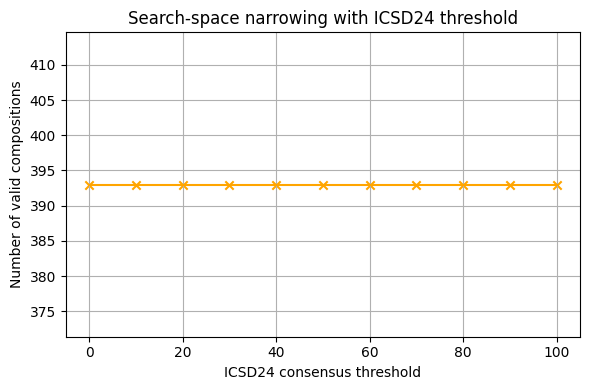

In [ ]:
from __future__ import annotations

import random

import numpy as np
import plotly.graph_objects as go
from pymatgen.core import Composition, Element

elements = ["Bi", "Te", "In"]

import itertools

from smact.screening import smact_validity

max_stoich = 8
all_compositions = [
    Composition({el: amt for el, amt in zip(elements, amt_list)}).reduced_composition
    for amt_list in itertools.product(range(max_stoich + 1), repeat=len(elements))
    if max(amt_list) > 0
]
valid_compositions = [
    comp for comp in all_compositions if smact_validity(comp)
]  # add ox threshold and see if it makes the phase diagram tighter-
unique_valid_compositions = list(set(valid_compositions))
print(f"Number of unique valid compositions: {len(unique_valid_compositions)} out of {len(all_compositions)}")

from smact.utils.oxidation import ICSD24OxStatesFilter

current_fname = "icsd24_current.txt"

# Initialise the oxidation state filter
ox_filter = ICSD24OxStatesFilter()
ox_states_df = ox_filter.ox_states_df
ox_states_df.head(15)

supplied_oxidation_states = [
    "smact14",
    "icsd24",
    "icsd16",
    "pymatgen_sp",
    "oxidation_states_icsd24_100.txt",
]
# Extract fractional compositions
e1 = np.array([comp[elements[0]] for comp in unique_valid_compositions])
e2 = np.array([comp[elements[1]] for comp in unique_valid_compositions])
e3 = np.array([comp[elements[2]] for comp in unique_valid_compositions])

# Normalize to get fractions
total = e1 + e2 + e3
e1 = e1 / total
e2 = e2 / total
e3 = e3 / total

# plot with line from origin_fig
fig = go.Figure()
# mp entries
fig.add_trace(
    go.Scatterternary(
        a=e1,
        b=e2,
        c=e3,
        mode="markers",
        marker=dict(
            size=6,
            color="green",
            symbol="circle",
            opacity=0.7,
        ),
        name="SMACT Valid",
        cliponaxis=False,
    )
)
# layout
axis_style = dict(
    title=dict(font=dict(size=10)),
    linewidth=1,
    linecolor="black",
    gridcolor="rgba(128, 128, 128, 0.2)",
    showticklabels=True,
    tickvals=[0.2, 0.4, 0.6, 0.8],
)
fig.update_layout(
    font=dict(size=10, family="Arial"),
    width=210,
    height=210,
    ternary=dict(
        bgcolor="rgba(0, 0, 0, 0)",
        aaxis=dict(axis_style, title=elements[0]),
        baxis=dict(axis_style, title=elements[1]),
        caxis=dict(axis_style, title=elements[2]),
    ),
    margin=dict(l=20, r=20, b=30, t=20),
    showlegend=False,
    legend=dict(
        x=0.65,
        y=1.08,
    ),
)
# Show the plot
fig.show()
# save image
# fig.write_image("figures/smact.pdf")

###############################################################################
# STEP 5: ICSD24 THRESHOLD SWEEP
###############################################################################
import matplotlib.pyplot as plt

# STEP 5: ICSD24 Threshold Narrowing Plot
# Count how many compositions survive each ICSD24 consensus threshold
icsd_filter = ICSD24OxStatesFilter()
thresholds = list(range(0, 101, 10))
counts = []
for thr in thresholds:
    icsd_filter.write(current_fname, consensus=thr, include_zero=False, commonality="low")
    valid_list = [comp for comp in all_compositions if smact_validity(comp, oxidation_states_set=current_fname)]
    counts.append(len(set(valid_list)))

# Plot the narrowing of the search space
plt.figure(figsize=(6, 4))
plt.scatter(thresholds, counts, color="orange", marker="x")
plt.plot(thresholds, counts, color="orange", linestyle="-")
plt.xlabel("ICSD24 consensus threshold")
plt.ylabel("Number of valid compositions")
plt.title("Search-space narrowing with ICSD24 threshold")
plt.grid(True)
plt.tight_layout()
plt.show()


Skipping In6BiTe: One or both of [In1, Te-3] are not in the probability table.
Skipping In3BiTe: One or both of [In2, Te-3] are not in the probability table.
Skipping In6BiTe3: One or both of [In2, Te-3] are not in the probability table.
Skipping In6Bi3Te: One or both of [In2, Te-3] are not in the probability table.
Skipping In2BiTe: One or both of [In3, Te-3] are not in the probability table.
Skipping In3BiTe2: One or both of [In3, Te-3] are not in the probability table.
Skipping In4BiTe3: One or both of [In3, Te-3] are not in the probability table.
Skipping In5BiTe4: One or both of [In3, Te-3] are not in the probability table.
Skipping In6BiTe5: One or both of [In3, Te-3] are not in the probability table.
Skipping In7BiTe6: One or both of [In3, Te-3] are not in the probability table.
Skipping In8BiTe7: One or both of [In3, Te-3] are not in the probability table.
Skipping In3Bi2Te: One or both of [In3, Te-3] are not in the probability table.
Skipping In5Bi2Te3: One or both of [In3, Te

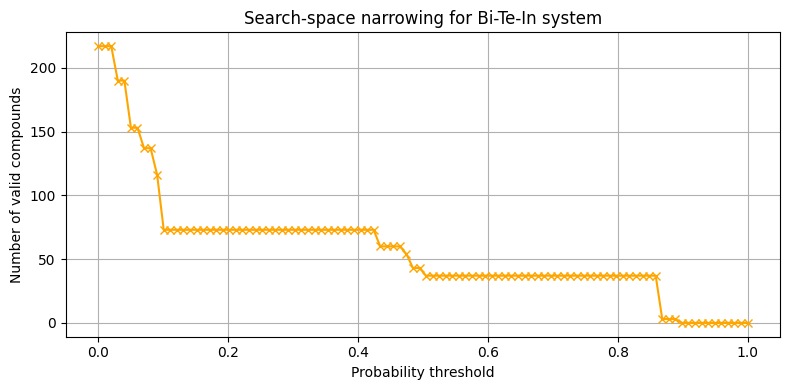

In [ ]:
#!/usr/bin/env python3
"""
Script: Oxidation-state probability analysis for Bi-Te-In system.

Generates plausible Bi-Te-In compositions via SMACT's smact_filter,
computes their compound probabilities using the oxidation-state probability model,
and plots how the search space narrows as a function of probability threshold.
"""

from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pymatgen.core import Composition

from smact import Element, Species
from smact.oxidation_states import Oxidation_state_probability_finder
from smact.screening import smact_filter


def main():
    # Instantiate the oxidation-state probability finder
    oxfinder = Oxidation_state_probability_finder()

    # Define the Bi-Te-In element system
    elements = [Element("Bi"), Element("Te"), Element("In")]

    # Generate plausible compositions (max stoich threshold = 8)
    comps = smact_filter(elements, threshold=8, oxidation_states_set="icsd24")

    # Prepare lists for species lists and formulas
    species_lists = []
    formulas = []
    for syms, oxs, ratios in comps:
        # Build list of SMACT Species objects
        slist = [Species(sym, ox) for sym, ox in zip(syms, oxs)]
        species_lists.append(slist)
        # Construct formula string and reduce it
        raw_formula = "".join(f"{sym}{amt}" for sym, amt in zip(syms, ratios))
        reduced = Composition(raw_formula).reduced_formula
        formulas.append(reduced)

    # Compute compound probabilities, skipping species not in probability table
    valid_formulas = []
    valid_probs = []
    for slist, formula in zip(species_lists, formulas):
        try:
            p = oxfinder.compound_probability(slist)
        except NameError as e:
            # Skip species pairs not in the probability table
            print(f"Skipping {formula}: {e}")
            continue
        valid_formulas.append(formula)
        valid_probs.append(p)

    # Create a DataFrame of successfully scored compounds
    df = pd.DataFrame({"formula_pretty": valid_formulas, "compound_probability": valid_probs})

    # Print example entries
    print("First 10 compounds and their probabilities:")
    print(df.head(10))

    # Threshold sweep: how many compounds exceed each probability threshold
    thresh_vals = np.linspace(0, 1, 100)
    counts = [(df.compound_probability >= t).sum() for t in thresh_vals]

    # Plot search-space narrowing
    plt.figure(figsize=(8, 4))
    plt.plot(thresh_vals, counts, marker="x", color="orange")
    plt.xlabel("Probability threshold")
    plt.ylabel("Number of valid compounds")
    plt.title("Search-space narrowing for Bi-Te-In system")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()



Skipping In6BiTe: One or both of [In1, Te-3] are not in the probability table.
Skipping In3BiTe: One or both of [In2, Te-3] are not in the probability table.
Skipping In6BiTe3: One or both of [In2, Te-3] are not in the probability table.
Skipping In6Bi3Te: One or both of [In2, Te-3] are not in the probability table.
Skipping In2BiTe: One or both of [In3, Te-3] are not in the probability table.
Skipping In3BiTe2: One or both of [In3, Te-3] are not in the probability table.
Skipping In4BiTe3: One or both of [In3, Te-3] are not in the probability table.
Skipping In5BiTe4: One or both of [In3, Te-3] are not in the probability table.
Skipping In6BiTe5: One or both of [In3, Te-3] are not in the probability table.
Skipping In7BiTe6: One or both of [In3, Te-3] are not in the probability table.
Skipping In8BiTe7: One or both of [In3, Te-3] are not in the probability table.
Skipping In3Bi2Te: One or both of [In3, Te-3] are not in the probability table.
Skipping In5Bi2Te3: One or both of [In3, Te

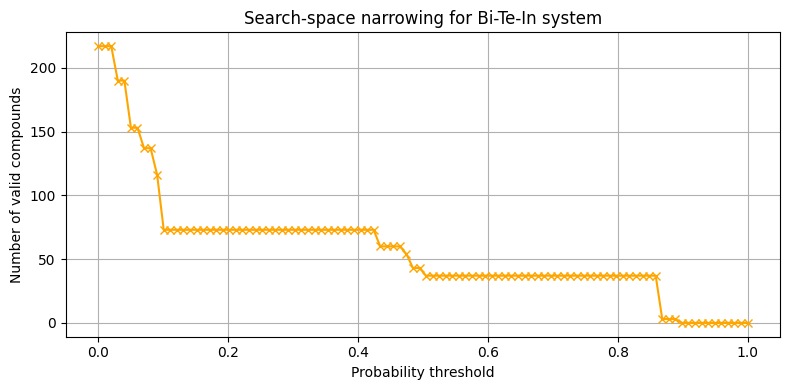

In [ ]:
#!/usr/bin/env python3
"""
Script: Oxidation-state probability analysis for Bi-Te-In system.

Generates plausible Bi-Te-In compositions via SMACT's smact_filter,
computes their compound probabilities using the oxidation-state probability model,
and plots how the search space narrows as a function of probability threshold.
"""

from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from pymatgen.core import Composition

from smact import Element, Species
from smact.oxidation_states import Oxidation_state_probability_finder
from smact.screening import smact_filter


def main():
    # Instantiate the oxidation-state probability finder
    oxfinder = Oxidation_state_probability_finder()

    # Define the Bi-Te-In element system
    elements = [Element("Bi"), Element("Te"), Element("In")]

    # Generate plausible compositions (max stoich threshold = 8)
    comps = smact_filter(elements, threshold=8, oxidation_states_set="icsd24")

    # Prepare lists for species lists and formulas
    species_lists = []
    formulas = []
    for syms, oxs, ratios in comps:
        # Build list of SMACT Species objects
        slist = [Species(sym, ox) for sym, ox in zip(syms, oxs)]
        species_lists.append(slist)
        # Construct formula string and reduce it
        raw_formula = "".join(f"{sym}{amt}" for sym, amt in zip(syms, ratios))
        reduced = Composition(raw_formula).reduced_formula
        formulas.append(reduced)

    # Compute compound probabilities, skipping species not in probability table
    valid_formulas = []
    valid_probs = []
    for slist, formula in zip(species_lists, formulas):
        try:
            p = oxfinder.compound_probability(slist)
        except NameError as e:
            # Skip species pairs not in the probability table
            print(f"Skipping {formula}: {e}")
            continue
        valid_formulas.append(formula)
        valid_probs.append(p)

    # Create a DataFrame of successfully scored compounds
    df = pd.DataFrame({"formula_pretty": valid_formulas, "compound_probability": valid_probs})

    # Print example entries
    print("First 10 compounds and their probabilities:")
    print(df.head(10))

    # Threshold sweep: how many compounds exceed each probability threshold
    thresh_vals = np.linspace(0, 1, 100)
    counts = [(df.compound_probability >= t).sum() for t in thresh_vals]

    # Plot search-space narrowing
    plt.figure(figsize=(8, 4))
    plt.plot(thresh_vals, counts, marker="x", color="orange")
    plt.xlabel("Probability threshold")
    plt.ylabel("Number of valid compounds")
    plt.title("Search-space narrowing for Bi-Te-In system")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------------------------------
    # Plotly ternary: composition distribution at various probability thresholds
    # Select probability thresholds to visualize
    prob_thresholds = [0.0, 0.2, 0.4, 0.6, 0.8]
    for thr in prob_thresholds:
        # Subset compounds above threshold
        df_thr = df[df.compound_probability >= thr]
        a_vals, b_vals, c_vals = [], [], []
        for formula in df_thr["formula_pretty"]:
            comp = Composition(formula)
            bi = comp.get("Bi", 0)
            te = comp.get("Te", 0)
            in_ = comp.get("In", 0)
            total = bi + te + in_
            a_vals.append(bi / total)
            b_vals.append(te / total)
            c_vals.append(in_ / total)
        fig_t = go.Figure()
        fig_t.add_trace(
            go.Scatterternary(
                a=a_vals, b=b_vals, c=c_vals, mode="markers", marker=dict(size=8, opacity=0.7), name=f"P ≥ {thr:.1f}"
            )
        )
        # Layout styling
        fig_t.update_layout(
            title=f"Bi-Te-In composition for P ≥ {thr:.1f}",
            font=dict(size=12),
            width=600,
            height=600,
            ternary=dict(
                aaxis=dict(title="Bi"),
                baxis=dict(title="Te"),
                caxis=dict(title="In"),
            ),
            margin=dict(l=50, r=50, b=50, t=50),
            showlegend=False,
        )
        fig_t.show()


if __name__ == "__main__":
    main()
